# 04 - Member 4: recommended loan amount (Model C)

**Owner:** Member 4  
**Dataset:** loan_approval_lk_synthetic.csv (Approved rows only)  
**Target:** loan_amount (regression)

Golden rule: import Member 1's pipeline. Do not write cleaning here.

The API later must apply 
ecommended_amount = min(requested_amount, model_prediction). That cap is **not** part of training.


In [1]:
%matplotlib inline


In [3]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'ml' / 'pipeline' / 'features.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.config import DATA_PROCESSED, DATA_RAW, FIGURES_DIR, MODELS_DIR, RANDOM_STATE, REPORTS_DIR, ensure_dirs
ensure_dirs()
print('Project root:', ROOT)


Project root: E:\ML\CREDIT-RISK-ASSESMENT-ML-Final


## Load Member 1 split (or rebuild the same 70/15/15)

loan_amount is dropped from X so it cannot leak. Training uses **Approved** applications only.


train/val/test = 1859/398/399  source=data/processed (Member 1)
target median=14,500,000  skew=0.281


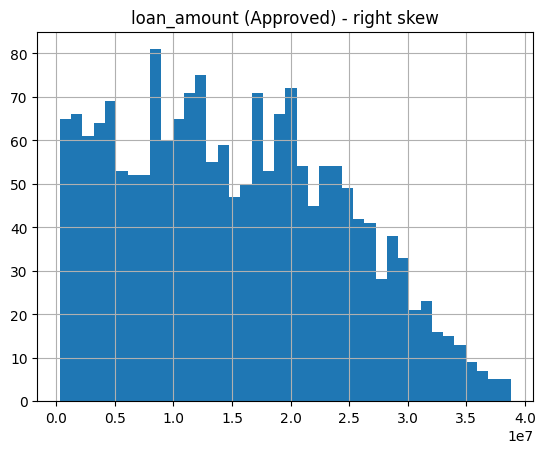

In [4]:
import json
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

from ml.pipeline.features import LoanAmountFeatures, strip_loan_frame

set_config(transform_output='pandas')

INFERENCE_RULE = 'recommended_amount = min(requested_amount, model_prediction)'

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mape': float(np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100),
    }

train_x = DATA_PROCESSED / 'c_train.parquet'
if train_x.exists():
    X_train = pd.read_parquet(train_x)
    X_val = pd.read_parquet(DATA_PROCESSED / 'c_val.parquet')
    X_test = pd.read_parquet(DATA_PROCESSED / 'c_test.parquet')
    y_train = pd.read_parquet(DATA_PROCESSED / 'yc_train.parquet').iloc[:, 0].astype(float)
    y_val = pd.read_parquet(DATA_PROCESSED / 'yc_val.parquet').iloc[:, 0].astype(float)
    y_test = pd.read_parquet(DATA_PROCESSED / 'yc_test.parquet').iloc[:, 0].astype(float)
    source = 'data/processed (Member 1)'
else:
    csv = DATA_RAW / 'loan_approval_lk_synthetic.csv'
    if not csv.exists():
        csv = ROOT / 'loan_approval_lk_synthetic.csv'
    loan_df = strip_loan_frame(pd.read_csv(csv))
    work = loan_df[loan_df['loan_status'] == 'Approved'].reset_index(drop=True)
    y = work['loan_amount'].astype(float)
    X = work.drop(columns=[c for c in ('loan_status', 'loan_id', 'loan_amount') if c in work.columns])
    strata = pd.qcut(y, q=5, duplicates='drop')
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=strata, random_state=RANDOM_STATE)
    temp_strata = pd.qcut(y_temp, q=min(5, y_temp.nunique()), duplicates='drop')
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=temp_strata, random_state=RANDOM_STATE)
    source = 'rebuilt approved-only 70/15/15'

assert 'loan_amount' not in X_train.columns
print(f'train/val/test = {len(X_train)}/{len(X_val)}/{len(X_test)}  source={source}')
print(f'target median={float(y_train.median()):,.0f}  skew={float(y_train.skew()):.3f}')
y_train.hist(bins=40)
plt.title('loan_amount (Approved) - right skew')
plt.show()


## Member 1 pipeline smoke test

LoanAmountFeatures is Member 1's Model C class: same file as LoanApprovalFeatures, but it never includes loan_amount.


In [5]:
preview = LoanAmountFeatures().fit(X_train).transform(X_train.head(5))
assert 'loan_amount' not in preview.columns
assert 'loan_to_income' not in preview.columns
print(list(preview.columns))
preview


['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'total_assets', 'assets_to_income', 'risk_tier']


,no_of_dependents,education,self_employed,income_annum,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,total_assets,assets_to_income,risk_tier
2003,3,Graduate,Yes,1000000,6,808,2900000,600000,2000000,500000,6000000,6.000000,Excellent
173,0,Not Graduate,Yes,9900000,6,573,17200000,10000000,20100000,5900000,53200000,5.373737,Poor
694,4,Not Graduate,No,2300000,8,676,6000000,400000,4800000,2200000,13400000,5.826087,Good
1605,1,Graduate,Yes,5800000,12,862,11300000,8400000,12000000,3900000,35600000,6.137931,Excellent
1450,3,Not Graduate,No,9200000,2,715,11100000,11800000,19800000,11700000,54400000,5.913043,Good


## Raw vs log1p target (document this for the report)


In [6]:
CAT_COLS = ['education', 'self_employed', 'risk_tier']

def make_preprocessor(sample):
    cat = [c for c in CAT_COLS if c in sample.columns]
    num = [c for c in sample.columns if c not in cat]
    return ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat),
         ('num', 'passthrough', num)],
        remainder='drop',
        verbose_feature_names_out=False,
    )

def make_xgb():
    return XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85, min_child_weight=4,
        tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE,
    )

def make_pipe(log_target):
    model = make_xgb()
    if log_target:
        model = TransformedTargetRegressor(
            regressor=model, func=np.log1p, inverse_func=np.expm1, check_inverse=False,
        )
    return Pipeline([
        ('features', LoanAmountFeatures()),
        ('preprocess', make_preprocessor(preview)),
        ('model', model),
    ])

raw_pipe, log_pipe = make_pipe(False), make_pipe(True)
raw_pipe.fit(X_train, y_train)
log_pipe.fit(X_train, y_train)
raw_val = regression_metrics(y_val, raw_pipe.predict(X_val))
log_val = regression_metrics(y_val, log_pipe.predict(X_val))
use_log = log_val['mae'] <= raw_val['mae']
pipe = log_pipe if use_log else raw_pipe
print(f'Val MAE raw={raw_val["mae"]:,.0f}  log1p={log_val["mae"]:,.0f}')
print('Chosen target transform:', 'log1p' if use_log else 'raw')


Val MAE raw=2,623,932  log1p=2,603,139
Chosen target transform: log1p


## Test metrics + plots


Test MAE=2,657,977  RMSE=3,621,365  MAPE=18.0%
API rule (not trained): recommended_amount = min(requested_amount, model_prediction)


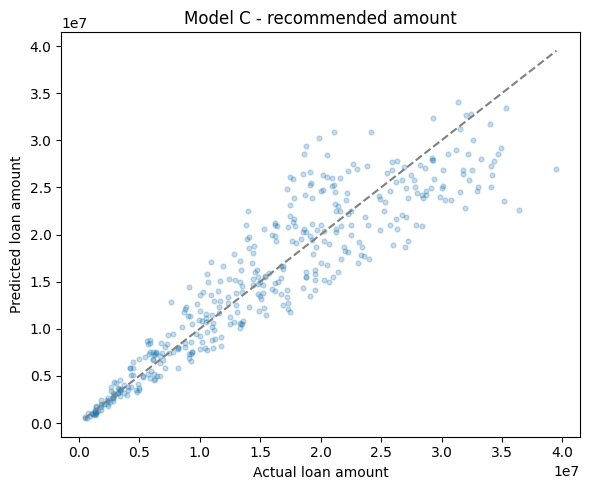

In [7]:
test_pred = pipe.predict(X_test)
test_metrics = regression_metrics(y_test, test_pred)
print(f'Test MAE={test_metrics["mae"]:,.0f}  RMSE={test_metrics["rmse"]:,.0f}  MAPE={test_metrics["mape"]:.1f}%')
print('API rule (not trained):', INFERENCE_RULE)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred, alpha=0.25, s=12)
lo, hi = min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())
plt.plot([lo, hi], [lo, hi], '--', color='gray')
plt.xlabel('Actual loan amount')
plt.ylabel('Predicted loan amount')
plt.title('Model C - recommended amount')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_c_pred_vs_actual.png', dpi=140)
plt.show()


## Day 6 SHAP (Member 4)


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


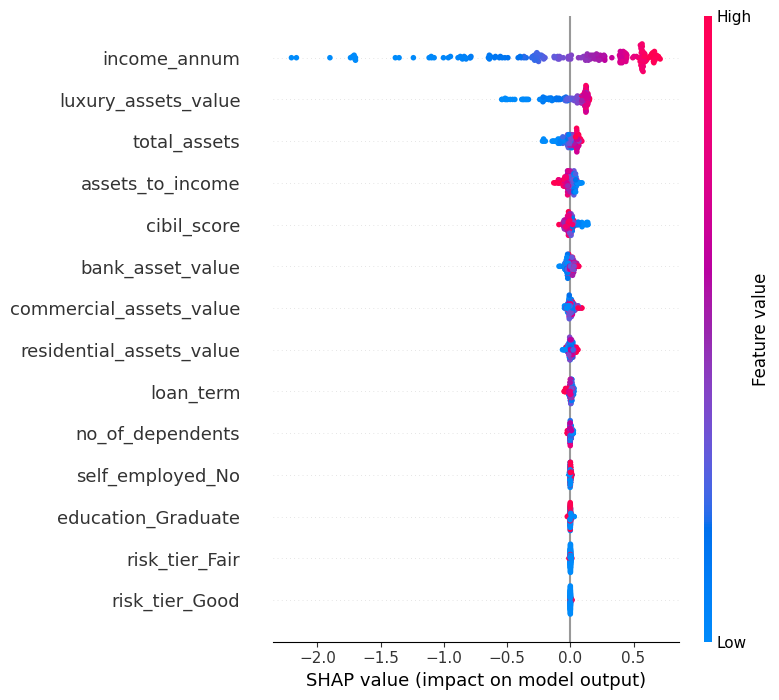

In [8]:
import shap

transformed = pipe.named_steps['preprocess'].transform(pipe.named_steps['features'].transform(X_test))
sample = transformed.sample(n=min(200, len(transformed)), random_state=1)
inner = pipe.named_steps['model']
if hasattr(inner, 'regressor_'):
    inner = inner.regressor_
shap.summary_plot(shap.TreeExplainer(inner).shap_values(sample), sample, show=False, max_display=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary_model_c.png', dpi=140, bbox_inches='tight')
plt.show()


## Inference sanity (API later — shown only)


In [9]:
requested = 20_000_000
predicted = float(pipe.predict(X_test.head(1))[0])
recommended = min(requested, predicted)
print(f'predicted={predicted:,.0f}  requested={requested:,.0f}  recommended={recommended:,.0f}  capped={recommended < predicted}')


predicted=27,194,736  requested=20,000,000  recommended=20,000,000  capped=True


## Save pkl + metrics log


In [10]:
log_note = (
    f'loan_amount is right-skewed (train skew={float(y_train.skew()):.2f}). '
    f'Raw-scale val MAE={raw_val["mae"]:,.0f}; log1p val MAE={log_val["mae"]:,.0f}. '
    f'Keep {"log1p" if use_log else "raw"}. Requested amount is not a feature. '
    f'{INFERENCE_RULE} belongs in the API.'
)
(REPORTS_DIR / 'model_c_log_transform.md').write_text(
    '# Model C - log-transform decision (Member 4)\n\n' + log_note + '\n', encoding='utf-8'
)

path = MODELS_DIR / 'model_c_amount.pkl'
joblib.dump(pipe, path)
meta = {
    'model_version': 'model_c_v2_lk',
    'owner': 'member_4',
    'target_transform': 'log1p / expm1' if use_log else 'none',
    'pipeline': 'ml.pipeline.features.LoanAmountFeatures',
    'metrics': {'val_raw': raw_val, 'val_log1p': log_val, 'test': test_metrics},
    'inference_rule': INFERENCE_RULE,
    'notes': log_note,
    'saved_at': datetime.now(timezone.utc).isoformat(),
}
(MODELS_DIR / 'model_c_amount.meta.json').write_text(json.dumps(meta, indent=2, default=str), encoding='utf-8')

metrics_path = REPORTS_DIR / 'metrics.json'
metrics = json.loads(metrics_path.read_text(encoding='utf-8')) if metrics_path.exists() else {}
metrics['model_c_amount'] = {
    'owner': 'member_4',
    'metric': 'MAE / RMSE (currency units)',
    'baseline_mae': raw_val['mae'],
    'tuned_mae': test_metrics['mae'],
    'tuned_rmse': test_metrics['rmse'],
    'tuned_mape': test_metrics['mape'],
    'target_transform': 'log1p' if use_log else 'raw',
    'trained_on': 'approved_applications_only',
    'inference_rule': INFERENCE_RULE,
}
metrics_path.write_text(json.dumps(metrics, indent=2, default=str), encoding='utf-8')

try:
    import mlflow
    mlflow.set_experiment('credit-risk-platform')
    with mlflow.start_run(run_name='model_c_xgb_regressor'):
        mlflow.log_param('owner', 'member_4')
        mlflow.log_param('target_transform', 'log1p' if use_log else 'raw')
        mlflow.log_metric('test_mae', test_metrics['mae'])
        mlflow.log_metric('test_rmse', test_metrics['rmse'])
except Exception as exc:
    print('MLflow skipped:', exc)

print('Saved', path)
print(log_note)


2026/09/13 20:26:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/13 20:26:55 INFO mlflow.store.db.utils: Updating database tables
2026/09/13 20:26:58 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-platform' does not exist. Creating a new experiment.


Saved E:\ML\CREDIT-RISK-ASSESMENT-ML-Final\ml\models\model_c_amount.pkl
loan_amount is right-skewed (train skew=0.28). Raw-scale val MAE=2,623,932; log1p val MAE=2,603,139. Keep log1p. Requested amount is not a feature. recommended_amount = min(requested_amount, model_prediction) belongs in the API.
